# 04 — Explicabilité du modèle d'attrition

## Objectif

Ce notebook vise à interpréter les prédictions produites par le modèle
de régression logistique développé précédemment.

L'analyse cherche à répondre à trois questions :

1. Quels facteurs influencent globalement les prédictions du modèle ?
2. Pourquoi un collaborateur donné reçoit-il un score d'attrition élevé
   ou faible ?
3. Comment restituer ces informations de manière exploitable dans
   Power BI ?

La régression logistique étant un modèle intrinsèquement interprétable,
l'analyse repose principalement sur ses coefficients et sur la
décomposition du logit individuel.

Les résultats décrivent le fonctionnement du modèle et des associations
statistiques. Ils ne doivent pas être interprétés comme des effets causaux.

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path


In [82]:
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")

MODEL_PATH = MODEL_DIR / "attrition_pipeline.joblib"
SCORING_PATH = OUTPUT_DIR / "employee_scoring.csv"
FACTORS_PATH = OUTPUT_DIR / "model_factors.csv"
DATA_MODEL = OUTPUT_DIR  / "df_model.csv"


In [83]:
model_pipeline = joblib.load(MODEL_PATH)

df_model = pd.read_csv(DATA_MODEL)

df_scoring = pd.read_csv(SCORING_PATH)
model_factors = pd.read_csv(FACTORS_PATH)

print("Scoring :", df_scoring.shape)
print("Facteurs :", model_factors.shape)


Scoring : (1470, 8)
Facteurs : (29, 7)


In [84]:
preprocessor = model_pipeline.named_steps["Preprocessor"]
classifier = model_pipeline.named_steps["Model"]

feature_names = preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

global_explanation = pd.DataFrame(
    {"Feature": feature_names, "Coefficient": coefficients}
)

global_explanation["AbsCoefficient"] = global_explanation["Coefficient"].abs()

global_explanation["Direction"] = np.where(
    global_explanation["Coefficient"] > 0, "Augmente le score", "Diminue le score"
)

global_explanation = global_explanation.sort_values("AbsCoefficient", ascending=False)

global_explanation.head(15)


,Feature,Coefficient,AbsCoefficient,Direction
11,categorical__OverTime_Yes,1.582737,1.582737,Augmente le score
22,categorical__BusinessTravel_Travel_Frequently,1.427311,1.427311,Augmente le score
19,categorical__JobRole_Sales Representative,1.311349,1.311349,Augmente le score
13,categorical__JobRole_Laboratory Technician,1.192438,1.192438,Augmente le score
16,categorical__JobRole_Research Director,-1.106089,1.106089,Diminue le score
27,categorical__EducationField_Other,-0.987697,0.987697,Diminue le score
12,categorical__JobRole_Human Resources,0.708907,0.708907,Augmente le score
18,categorical__JobRole_Sales Executive,0.701930,0.701930,Augmente le score
23,categorical__BusinessTravel_Travel_Rarely,0.640278,0.640278,Augmente le score
26,categorical__EducationField_Medical,-0.555765,0.555765,Diminue le score


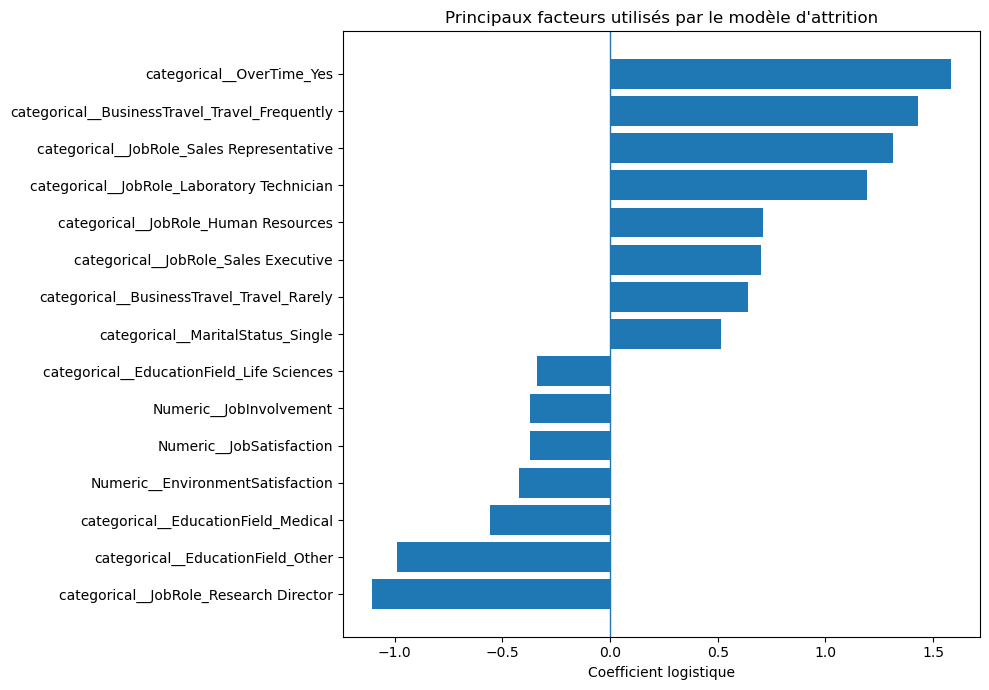

In [85]:
top_factors = global_explanation.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(top_factors["Feature"], top_factors["Coefficient"])

plt.axvline(0, linewidth=1)

plt.xlabel("Coefficient logistique")
plt.ylabel("")
plt.title("Principaux facteurs utilisés par le modèle d'attrition")

plt.tight_layout()
plt.show()


In [86]:
numeric_features = [
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "MonthlyIncome",
    "StockOptionLevel",
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "DistanceFromHome",
]

categorical_features = [
    "OverTime",
    "JobRole",
    "MaritalStatus",
    "BusinessTravel",
    "EducationField",
    # "Department",
]

selected_features = numeric_features + categorical_features


In [87]:
def explain_employee(employee_number, top_n=10):
    # Collaborateur à expliquer
    employee = df_model.loc[
        df_model["EmployeeNumber"] == employee_number, selected_features
    ]

    if employee.empty:
        raise ValueError(f"EmployeeNumber {employee_number} introuvable.")

    # Transformation avec le preprocessing du modèle
    X_transformed = preprocessor.transform(employee)

    # Passage en tableau dense si nécessaire
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    values = np.asarray(X_transformed)[0]

    # Contribution = valeur transformée × coefficient
    contributions = values * coefficients

    explanation = pd.DataFrame(
        {
            "Feature": feature_names,
            "TransformedValue": values,
            "Coefficient": coefficients,
            "Contribution": contributions,
        }
    )

    explanation["AbsContribution"] = explanation["Contribution"].abs()

    explanation["Direction"] = np.where(
        explanation["Contribution"] > 0,
        "Augmente le score",
        np.where(explanation["Contribution"] < 0, "Diminue le score", "Neutre"),
    )

    explanation = explanation.sort_values("AbsContribution", ascending=False)

    probability = model_pipeline.predict_proba(employee)[0, 1]

    return probability, explanation.head(top_n)


In [88]:
high_risk_employee = df_scoring.sort_values(
    "AttritionProbability", ascending=False
).iloc[0]

high_risk_employee[["EmployeeNumber", "Attrition", "AttritionProbability", "RiskLevel"]]


EmployeeNumber               478
Attrition                    Yes
AttritionProbability    0.969889
RiskLevel               Critique
Name: 357, dtype: object

In [89]:
employee_number = int(high_risk_employee["EmployeeNumber"])

probability, explanation = explain_employee(employee_number, top_n=10)

print(f"EmployeeNumber : {employee_number}")

print(f"Probabilité d'attrition : {probability:.1%}")

explanation.round(3)


EmployeeNumber : 478
Probabilité d'attrition : 97.0%


,Feature,TransformedValue,Coefficient,Contribution,AbsContribution,Direction
11,categorical__OverTime_Yes,1.000,1.583,1.583,1.583,Augmente le score
22,categorical__BusinessTravel_Travel_Frequently,1.000,1.427,1.427,1.427,Augmente le score
19,categorical__JobRole_Sales Representative,1.000,1.311,1.311,1.311,Augmente le score
9,Numeric__EnvironmentSatisfaction,-1.578,-0.422,0.666,0.666,Augmente le score
21,categorical__MaritalStatus_Single,1.000,0.517,0.517,0.517,Augmente le score
0,Numeric__Age,-1.744,-0.290,0.506,0.506,Augmente le score
7,Numeric__JobInvolvement,-1.048,-0.371,0.389,0.389,Augmente le score
10,Numeric__DistanceFromHome,-1.022,0.340,-0.347,0.347,Diminue le score
6,Numeric__StockOptionLevel,-0.935,-0.328,0.307,0.307,Augmente le score
1,Numeric__TotalWorkingYears,-1.073,-0.229,0.246,0.246,Augmente le score


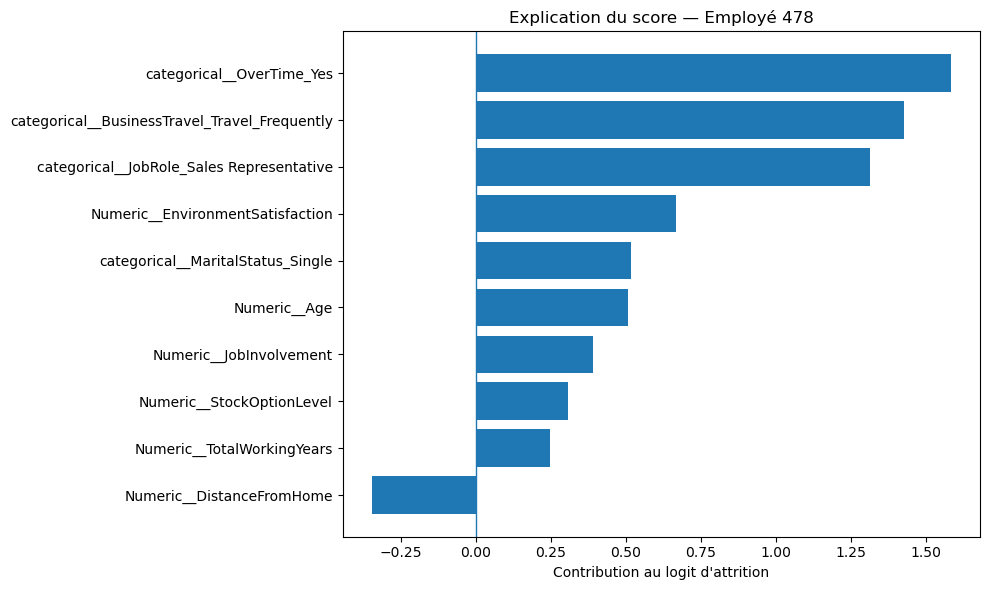

In [90]:
plot_data = explanation.sort_values("Contribution")

plt.figure(figsize=(10, 6))

plt.barh(plot_data["Feature"], plot_data["Contribution"])

plt.axvline(0, linewidth=1)

plt.xlabel("Contribution au logit d'attrition")

plt.ylabel("")

plt.title(f"Explication du score — Employé {employee_number}")

plt.tight_layout()
plt.show()


In [91]:
# Variables utilisées par le modèle
X_all = df_model[selected_features].copy()

# Transformation avec le preprocessing du pipeline
X_all_transformed = preprocessor.transform(X_all)

if hasattr(X_all_transformed, "toarray"):
    X_all_transformed = X_all_transformed.toarray()

X_all_transformed = np.asarray(X_all_transformed)

# Contribution = valeur transformée × coefficient
contribution_matrix = X_all_transformed * coefficients

print("Dimensions :", contribution_matrix.shape)


Dimensions : (1470, 29)


In [92]:
contributions_df = pd.DataFrame(
    contribution_matrix, columns=feature_names, index=df_model.index
)

contributions_df.insert(0, "EmployeeNumber", df_model["EmployeeNumber"].values)

employee_explanations = contributions_df.melt(
    id_vars="EmployeeNumber", var_name="Factor", value_name="Contribution"
)

employee_explanations["AbsContribution"] = employee_explanations["Contribution"].abs()

employee_explanations["Direction"] = np.select(
    [
        employee_explanations["Contribution"] > 0,
        employee_explanations["Contribution"] < 0,
    ],
    ["Augmente le score", "Diminue le score"],
    default="Neutre",
)

employee_explanations["Rank"] = (
    employee_explanations.groupby("EmployeeNumber")["AbsContribution"]
    .rank(method="first", ascending=False)
    .astype(int)
)


In [93]:
employee_explanations["FactorLabel"] = (
    employee_explanations["Factor"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("Numeric__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

employee_explanations_export = (
    employee_explanations[employee_explanations["Rank"] <= 10]
    .sort_values(["EmployeeNumber", "Rank"])
    .copy()
)

employee_explanations_export.to_csv(
    OUTPUT_DIR / "employee_explanations.csv", index=False
)

print(employee_explanations_export.shape)

employee_explanations_export[
    employee_explanations_export["EmployeeNumber"] == 478
].head(10).round(3)


(14700, 7)


,EmployeeNumber,Factor,Contribution,AbsContribution,Direction,Rank,FactorLabel
16527,478,categorical__OverTime_Yes,1.583,1.583,Augmente le score,1,OverTime Yes
32697,478,categorical__BusinessTravel_Travel_Frequently,1.427,1.427,Augmente le score,2,BusinessTravel Travel Frequently
28287,478,categorical__JobRole_Sales Representative,1.311,1.311,Augmente le score,3,JobRole Sales Representative
13587,478,Numeric__EnvironmentSatisfaction,0.666,0.666,Augmente le score,4,EnvironmentSatisfaction
31227,478,categorical__MaritalStatus_Single,0.517,0.517,Augmente le score,5,MaritalStatus Single
357,478,Numeric__Age,0.506,0.506,Augmente le score,6,Age
10647,478,Numeric__JobInvolvement,0.389,0.389,Augmente le score,7,JobInvolvement
15057,478,Numeric__DistanceFromHome,-0.347,0.347,Diminue le score,8,DistanceFromHome
9177,478,Numeric__StockOptionLevel,0.307,0.307,Augmente le score,9,StockOptionLevel
1827,478,Numeric__TotalWorkingYears,0.246,0.246,Augmente le score,10,TotalWorkingYears


In [94]:
employee_explanations["FactorLabel"] = (
    employee_explanations["Factor"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("Numeric__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

employee_explanations_export = (
    employee_explanations[employee_explanations["Rank"] <= 10]
    .sort_values(["EmployeeNumber", "Rank"])
    .copy()
)

employee_explanations_export.to_csv(
    OUTPUT_DIR / "employee_explanations.csv", index=False
)

print(employee_explanations_export.shape)

employee_explanations_export[
    employee_explanations_export["EmployeeNumber"] == 478
].head(10).round(3)


(14700, 7)


,EmployeeNumber,Factor,Contribution,AbsContribution,Direction,Rank,FactorLabel
16527,478,categorical__OverTime_Yes,1.583,1.583,Augmente le score,1,OverTime Yes
32697,478,categorical__BusinessTravel_Travel_Frequently,1.427,1.427,Augmente le score,2,BusinessTravel Travel Frequently
28287,478,categorical__JobRole_Sales Representative,1.311,1.311,Augmente le score,3,JobRole Sales Representative
13587,478,Numeric__EnvironmentSatisfaction,0.666,0.666,Augmente le score,4,EnvironmentSatisfaction
31227,478,categorical__MaritalStatus_Single,0.517,0.517,Augmente le score,5,MaritalStatus Single
357,478,Numeric__Age,0.506,0.506,Augmente le score,6,Age
10647,478,Numeric__JobInvolvement,0.389,0.389,Augmente le score,7,JobInvolvement
15057,478,Numeric__DistanceFromHome,-0.347,0.347,Diminue le score,8,DistanceFromHome
9177,478,Numeric__StockOptionLevel,0.307,0.307,Augmente le score,9,StockOptionLevel
1827,478,Numeric__TotalWorkingYears,0.246,0.246,Augmente le score,10,TotalWorkingYears


In [95]:
# Variables utiles pour l'explication
employee_values = df_model[["EmployeeNumber"] + selected_features].copy()

employee_explanations = employee_explanations.merge(
    employee_values, on="EmployeeNumber", how="left"
)

factor_labels = {
    "Numeric__Age": "Âge",
    "Numeric__TotalWorkingYears": "Expérience professionnelle",
    "Numeric__YearsAtCompany": "Ancienneté dans l'entreprise",
    "Numeric__YearsInCurrentRole": "Ancienneté dans le poste",
    "Numeric__YearsWithCurrManager": "Ancienneté avec le manager",
    "Numeric__MonthlyIncome": "Revenu mensuel",
    "Numeric__StockOptionLevel": "Stock-options",
    "Numeric__JobInvolvement": "Implication professionnelle",
    "Numeric__JobSatisfaction": "Satisfaction professionnelle",
    "Numeric__EnvironmentSatisfaction": "Satisfaction environnementale",
    "Numeric__DistanceFromHome": "Distance domicile-travail",
    "categorical__OverTime_Yes": "Heures supplémentaires",
    "categorical__BusinessTravel_Travel_Frequently": "Déplacements fréquents",
    "categorical__BusinessTravel_Travel_Rarely": "Déplacements occasionnels",
    "categorical__JobRole_Sales Representative": "Métier : Sales Representative",
    "categorical__JobRole_Laboratory Technician": "Métier : Laboratory Technician",
    "categorical__JobRole_Sales Executive": "Métier : Sales Executive",
    "categorical__MaritalStatus_Single": "Situation familiale : célibataire",
}

employee_explanations["FactorLabel"] = (
    employee_explanations["Factor"]
    .map(factor_labels)
    .fillna(employee_explanations["FactorLabel"])
)


In [96]:
employee_explanations_export = (
    employee_explanations[employee_explanations["Rank"] <= 10]
    .sort_values(["EmployeeNumber", "Rank"])
    .copy()
)

employee_explanations_export[
    [
        "EmployeeNumber",
        "Factor",
        "FactorLabel",
        "Contribution",
        "AbsContribution",
        "Direction",
        "Rank",
    ]
].to_csv(OUTPUT_DIR / "employee_explanations.csv", index=False)

employee_explanations_export.loc[
    employee_explanations_export["EmployeeNumber"] == 478,
    ["FactorLabel", "Contribution", "Direction", "Rank"],
].head(10).round(3)


,FactorLabel,Contribution,Direction,Rank
16527,Heures supplémentaires,1.583,Augmente le score,1
32697,Déplacements fréquents,1.427,Augmente le score,2
28287,Métier : Sales Representative,1.311,Augmente le score,3
13587,Satisfaction environnementale,0.666,Augmente le score,4
31227,Situation familiale : célibataire,0.517,Augmente le score,5
357,Âge,0.506,Augmente le score,6
10647,Implication professionnelle,0.389,Augmente le score,7
15057,Distance domicile-travail,-0.347,Diminue le score,8
9177,Stock-options,0.307,Augmente le score,9
1827,Expérience professionnelle,0.246,Augmente le score,10


In [97]:
 preprocessor.named_transformers_

{'Numeric': Pipeline(steps=[('Scaler', StandardScaler())]),
 'categorical': Pipeline(steps=[('OneHot',
                  OneHotEncoder(drop='first', handle_unknown='ignore'))])}

In [98]:
numeric_stats


,Variable,MeanTrain,StdTrain
0,Age,36.998299,9.174239
1,TotalWorkingYears,11.364796,7.798074
2,YearsAtCompany,7.050170,6.084023
3,YearsInCurrentRole,4.231293,3.567985
4,YearsWithCurrManager,4.196429,3.563279
5,MonthlyIncome,6544.024660,4651.764902
6,StockOptionLevel,0.790816,0.845426
7,JobInvolvement,2.737245,0.703374
8,JobSatisfaction,2.719388,1.110172
9,EnvironmentSatisfaction,2.716837,1.088244


In [99]:
employee_lookup = df_model.set_index("EmployeeNumber")
# value = row[variable]


In [100]:
 # Variables numériques utilisées par le modèle
numeric_scaler = preprocessor.named_transformers_["Numeric"].named_steps["Scaler"]

numeric_stats = pd.DataFrame(
    {
        "Variable": numeric_features,
        "MeanTrain": numeric_scaler.mean_,
        "StdTrain": numeric_scaler.scale_,
    }
)

numeric_labels = {
    "Age": ("Âge", "m"),
    "TotalWorkingYears": ("Expérience professionnelle", "f"),
    "YearsAtCompany": ("Ancienneté dans l'entreprise", "f"),
    "YearsInCurrentRole": ("Ancienneté dans le poste", "f"),
    "YearsWithCurrManager": ("Ancienneté avec le manager", "f"),
    "MonthlyIncome": ("Revenu mensuel", "m"),
    "StockOptionLevel": ("Niveau de stock-options", "m"),
    "JobInvolvement": ("Implication professionnelle", "f"),
    "JobSatisfaction": ("Satisfaction professionnelle", "f"),
    "EnvironmentSatisfaction": ("Satisfaction environnementale", "f"),
    "DistanceFromHome": ("Distance domicile-travail", "f"),
}

mean_dict = dict(zip(numeric_stats["Variable"], numeric_stats["MeanTrain"]))

def build_explanation(row):
    factor = row["Factor"]

    if factor.startswith("Numeric__"):
        variable = factor.replace("Numeric__", "")

        value = employee_lookup.loc[row["EmployeeNumber"], variable]

        mean_value = mean_dict[variable]

        label, gender = numeric_labels.get(variable, (variable, "m"))

        if value < mean_value:
            position = (
                "inférieure à la moyenne" if gender == "f" else "inférieur à la moyenne"
            )

        elif value > mean_value:
            position = (
                "supérieure à la moyenne" if gender == "f" else "supérieur à la moyenne"
            )

        else:
            position = "proche de la moyenne"

        return f"{label} {position} ({value:.1f} vs {mean_value:.1f})"

    return row["FactorLabel"]


employee_explanations["ExplanationLabel"] = employee_explanations.apply(
    build_explanation, axis=1
)

In [101]:
employee_explanations.loc[
    employee_explanations["EmployeeNumber"] == 478,
    ["FactorLabel", "ExplanationLabel", "Contribution", "Direction", "Rank"],
].sort_values("Rank").head(10)


,FactorLabel,ExplanationLabel,Contribution,Direction,Rank
16527,Heures supplémentaires,Heures supplémentaires,1.582737,Augmente le score,1
32697,Déplacements fréquents,Déplacements fréquents,1.427311,Augmente le score,2
28287,Métier : Sales Representative,Métier : Sales Representative,1.311349,Augmente le score,3
13587,Satisfaction environnementale,Satisfaction environnementale inférieure à la ...,0.666146,Augmente le score,4
31227,Situation familiale : célibataire,Situation familiale : célibataire,0.516825,Augmente le score,5
357,Âge,Âge inférieur à la moyenne (21.0 vs 37.0),0.506080,Augmente le score,6
10647,Implication professionnelle,Implication professionnelle inférieure à la mo...,0.388658,Augmente le score,7
15057,Distance domicile-travail,Distance domicile-travail inférieure à la moye...,-0.347326,Diminue le score,8
9177,Stock-options,Niveau de stock-options inférieur à la moyenne...,0.306565,Augmente le score,9
1827,Expérience professionnelle,Expérience professionnelle inférieure à la moy...,0.245830,Augmente le score,10


In [102]:
employee_explanations_export = (
    employee_explanations[employee_explanations["Rank"] <= 10]
    .sort_values(["EmployeeNumber", "Rank"])
    .copy()
)

columns_export = [
    "EmployeeNumber",
    "Factor",
    "FactorLabel",
    "ExplanationLabel",
    "Contribution",
    "AbsContribution",
    "Direction",
    "Rank",
]

employee_explanations_export[columns_export].to_csv(
    OUTPUT_DIR / "employee_explanations.csv", index=False, encoding="utf-8-sig"
)

employee_explanations_export.loc[
    employee_explanations_export["EmployeeNumber"] == 478,
    [
        "ExplanationLabel",
        "Contribution",
        "Direction",
        "Rank",
    ],
].head(10).round(3)


,ExplanationLabel,Contribution,Direction,Rank
16527,Heures supplémentaires,1.583,Augmente le score,1
32697,Déplacements fréquents,1.427,Augmente le score,2
28287,Métier : Sales Representative,1.311,Augmente le score,3
13587,Satisfaction environnementale inférieure à la ...,0.666,Augmente le score,4
31227,Situation familiale : célibataire,0.517,Augmente le score,5
357,Âge inférieur à la moyenne (21.0 vs 37.0),0.506,Augmente le score,6
10647,Implication professionnelle inférieure à la mo...,0.389,Augmente le score,7
15057,Distance domicile-travail inférieure à la moye...,-0.347,Diminue le score,8
9177,Niveau de stock-options inférieur à la moyenne...,0.307,Augmente le score,9
1827,Expérience professionnelle inférieure à la moy...,0.246,Augmente le score,10


In [107]:
RANDOM_STATE = 42


In [110]:
from sklearn.model_selection import train_test_split

In [112]:
numeric_features = [
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "MonthlyIncome",
    "StockOptionLevel",
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "DistanceFromHome",
]

categorical_features = [
    "OverTime",
    "JobRole",
    "MaritalStatus",
    "BusinessTravel",
    "EducationField",
    # "Department",
]

selected_features = numeric_features + categorical_features

X = df_model[selected_features].copy()
y = df_model["AttritionFlag"]


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

print("\nAttrition train :", y_train.mean().round(4))

print("Attrition test :", y_test.mean().round(4))


Train : (1176, 16)
Test  : (294, 16)

Attrition train : 0.1616
Attrition test : 0.1599


In [114]:
from sklearn.ensemble import RandomForestClassifier

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest = RandomForestClassifier(
    n_estimators=500, random_state=RANDOM_STATE, class_weight=None, n_jobs=-1
)

rf_pipeline = Pipeline([("preprocessor", preprocessor), ("model", random_forest)])

rf_pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Numeric',
                                                  Pipeline(steps=[('Scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'TotalWorkingYears',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsWithCurrManager',
                                                   'MonthlyIncome',
                                                   'StockOptionLevel',
                                                   'JobInvolvement',
                                                   'JobSatisfaction',
                                                   'EnvironmentSatisfaction',
                                                   'DistanceFromHome']),
                                                 ('categorical',
                                                  Pipeline(steps=[('OneHot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['OverTime', 'JobRole',
                                                   'MaritalStatus',
                                                   'BusinessTravel',
                                                   'EducationField'])])),
                ('model',
                 RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                        random_state=42))])

In [117]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
)

rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_pred = (rf_proba >= 0.5).astype(int)

rf_roc_auc = roc_auc_score(y_test, rf_proba)

rf_pr_auc = average_precision_score(y_test, rf_proba)

print(f"ROC-AUC : {rf_roc_auc:.3f}")

print(f"PR-AUC  : {rf_pr_auc:.3f}")

print()

print(classification_report(y_test, rf_pred, digits=3))


ROC-AUC : 0.816
PR-AUC  : 0.448

              precision    recall  f1-score   support

           0      0.850     0.964     0.903       247
           1      0.357     0.106     0.164        47

    accuracy                          0.827       294
   macro avg      0.604     0.535     0.534       294
weighted avg      0.771     0.827     0.785       294



In [119]:
comparison_models = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "ROC_AUC": [0.779, rf_roc_auc],
        "PR_AUC": [0.535, rf_pr_auc],
    }
)

comparison_models


,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.779000,0.53500
1,Random Forest,0.816436,0.44778


In [120]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"ROC_AUC": "roc_auc", "PR_AUC": "average_precision"}

models = {"Logistic Regression": model_pipeline, "Random Forest": rf_pipeline}

cv_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_results.append(
        {
            "Model": name,
            "ROC_AUC_mean": scores["test_ROC_AUC"].mean(),
            "ROC_AUC_std": scores["test_ROC_AUC"].std(),
            "PR_AUC_mean": scores["test_PR_AUC"].mean(),
            "PR_AUC_std": scores["test_PR_AUC"].std(),
        }
    )

cv_comparison = pd.DataFrame(cv_results)

cv_comparison.round(3)


,Model,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
0,Logistic Regression,0.819,0.030,0.610,0.067
1,Random Forest,0.794,0.035,0.538,0.083


In [123]:
model_selection = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "ROC_AUC_CV": [0.819, 0.794],
        "ROC_AUC_STD": [0.030, 0.035],
        "PR_AUC_CV": [0.610, 0.538],
        "PR_AUC_STD": [0.067, 0.083],
        "ROC_AUC_Test": [0.779, 0.816],
        "PR_AUC_Test": [0.535, 0.448],
        "Selected": [True, False],
    }
)

model_selection


,Model,ROC_AUC_CV,ROC_AUC_STD,PR_AUC_CV,PR_AUC_STD,ROC_AUC_Test,PR_AUC_Test,Selected
0,Logistic Regression,0.819,0.030,0.610,0.067,0.779,0.535,True
1,Random Forest,0.794,0.035,0.538,0.083,0.816,0.448,False


In [124]:
model_selection.to_csv(
    OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig"
)


## Sélection du modèle final

La régression logistique est retenue comme modèle final.

Bien que le Random Forest obtienne un ROC-AUC supérieur sur le jeu de test
(0,816 contre 0,779), cet avantage n'est pas confirmé en validation croisée.

Sur 5 folds, la régression logistique obtient de meilleures performances
moyennes :

- ROC-AUC : 0,819 ± 0,030 contre 0,794 ± 0,035 ;
- PR-AUC : 0,610 ± 0,067 contre 0,538 ± 0,083.

Le PR-AUC est particulièrement pertinent dans ce contexte en raison du
déséquilibre de la variable cible (~16 % de départs).

La régression logistique offre ainsi le meilleur compromis entre performance,
stabilité et interprétabilité. Elle est conservée comme modèle principal pour
le scoring et l'explicabilité des prédictions.

Le seuil de classification retenu reste 0,319, sélectionné sur les données
d'entraînement par validation croisée afin de maximiser le F1-score.

Les prédictions constituent des scores de risque et non des certitudes ou
des relations causales.

In [126]:
final_model_summary = pd.DataFrame(
    {
        "Indicateur": [
            "Modèle final",
            "ROC-AUC test",
            "PR-AUC test",
            "ROC-AUC CV",
            "PR-AUC CV",
            "Seuil retenu",
            "Brier Score",
            "Top 10% - départs captés",
            "Top 25% - départs captés",
        ],
        "Valeur": [
            "Logistic Regression",
            "0.779",
            "0.535",
            "0.819 ± 0.030",
            "0.610 ± 0.067",
            "0.319",
            "0.1048",
            "43.9%",
            "70.5%",
        ],
    }
)

final_model_summary


,Indicateur,Valeur
0,Modèle final,Logistic Regression
1,ROC-AUC test,0.779
2,PR-AUC test,0.535
3,ROC-AUC CV,0.819 ± 0.030
4,PR-AUC CV,0.610 ± 0.067
5,Seuil retenu,0.319
6,Brier Score,0.1048
7,Top 10% - départs captés,43.9%
8,Top 25% - départs captés,70.5%


In [127]:
final_model_summary.to_csv(
    OUTPUT_DIR / "model_summary.csv", index=False, encoding="utf-8-sig"
)


# Conclusion — Prédiction et explicabilité de l'attrition

La régression logistique est retenue comme modèle final pour l'estimation
du risque d'attrition.

En validation croisée, elle obtient un ROC-AUC moyen de 0,819 ± 0,030
et un PR-AUC moyen de 0,610 ± 0,067, surpassant le Random Forest
(ROC-AUC = 0,794 ; PR-AUC = 0,538).

Sur le jeu de test indépendant, le modèle atteint un ROC-AUC de 0,779
et un PR-AUC de 0,535.

Le seuil de classification de 0,319, sélectionné par validation croisée
sur les données d'entraînement, permet d'améliorer la détection des départs
par rapport au seuil standard de 0,50.

L'analyse des coefficients et des contributions individuelles permet
d'expliquer les principaux facteurs associés aux scores produits par le modèle.

Les scores permettent également de prioriser les profils :
les 25 % de collaborateurs présentant les scores les plus élevés concentrent
70,5 % des départs observés dans l'échantillon scoré.

Ces résultats doivent être interprétés comme des associations et des scores
de risque, et non comme des relations causales ou des certitudes de départ.

Le modèle constitue un outil analytique d'aide à la compréhension et à la
priorisation des actions RH, et non un système automatisé de décision
concernant les collaborateurs.